In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout


In [2]:
df = pd.read_csv("emotions (1).csv")

df.head()

,# mean_0_a,mean_1_a,mean_2_a,mean_3_a,mean_4_a,mean_d_0_a,mean_d_1_a,mean_d_2_a,mean_d_3_a,mean_d_4_a,...,fft_741_b,fft_742_b,fft_743_b,fft_744_b,fft_745_b,fft_746_b,fft_747_b,fft_748_b,fft_749_b,label
0,4.62,30.3,-356.0,15.6,26.3,1.070,0.411,-15.70,2.06,3.15,...,23.5,20.3,20.3,23.5,-215.0,280.00,-162.00,-162.00,280.00,NEGATIVE
1,28.80,33.1,32.0,25.8,22.8,6.550,1.680,2.88,3.83,-4.82,...,-23.3,-21.8,-21.8,-23.3,182.0,2.57,-31.60,-31.60,2.57,NEUTRAL
2,8.90,29.4,-416.0,16.7,23.7,79.900,3.360,90.20,89.90,2.03,...,462.0,-233.0,-233.0,462.0,-267.0,281.00,-148.00,-148.00,281.00,POSITIVE
3,14.90,31.6,-143.0,19.8,24.3,-0.584,-0.284,8.82,2.30,-1.97,...,299.0,-243.0,-243.0,299.0,132.0,-12.40,9.53,9.53,-12.40,POSITIVE
4,28.30,31.3,45.2,27.3,24.5,34.800,-5.790,3.06,41.40,5.52,...,12.0,38.1,38.1,12.0,119.0,-17.60,23.90,23.90,-17.60,NEUTRAL


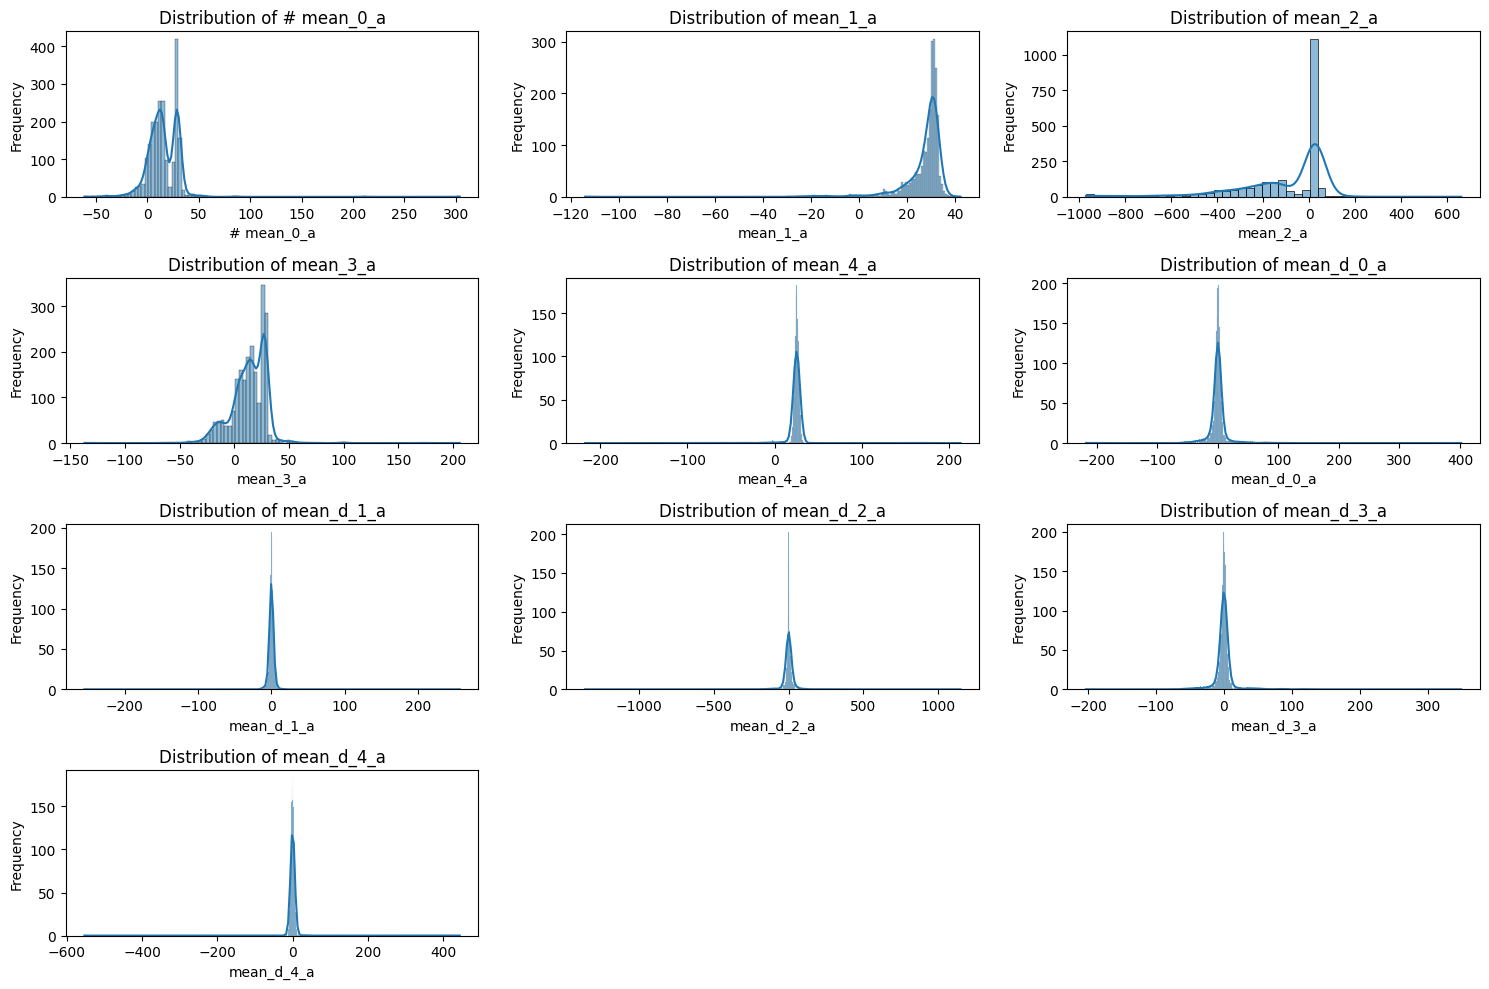

In [3]:
label_column = 'label'
feature_columns = [col for col in df.columns if col != label_column]

selected_features = feature_columns[:10]
plt.figure(figsize=(15, 10))
for i, feature in enumerate(selected_features):
    plt.subplot(4, 3, i + 1)
    sns.histplot(df[feature], kde=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [4]:
print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns)

Dataset shape: (2132, 2549)

Columns:
Index(['# mean_0_a', 'mean_1_a', 'mean_2_a', 'mean_3_a', 'mean_4_a',
       'mean_d_0_a', 'mean_d_1_a', 'mean_d_2_a', 'mean_d_3_a', 'mean_d_4_a',
       ...
       'fft_741_b', 'fft_742_b', 'fft_743_b', 'fft_744_b', 'fft_745_b',
       'fft_746_b', 'fft_747_b', 'fft_748_b', 'fft_749_b', 'label'],
      dtype='object', length=2549)


In [5]:
df.isna().sum()

,0
# mean_0_a,0
mean_1_a,0
mean_2_a,0
mean_3_a,0
mean_4_a,0
...,...
fft_746_b,0
fft_747_b,0
fft_748_b,0
fft_749_b,0


In [6]:
df.dropna(inplace=True)

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isna().sum()

,0
# mean_0_a,0
mean_1_a,0
mean_2_a,0
mean_3_a,0
mean_4_a,0
...,...
fft_746_b,0
fft_747_b,0
fft_748_b,0
fft_749_b,0


In [9]:
label_column = 'label'

feature_columns = [col for col in df.columns if col != label_column]

print("Number of feature columns:", len(feature_columns))
print("Label column:", label_column)

Number of feature columns: 2548
Label column: label


In [10]:
emotion_classes = df[label_column].unique()
print("Emotion classes:", emotion_classes)
print("Number of emotion classes:", len(emotion_classes))

Emotion classes: ['NEGATIVE' 'NEUTRAL' 'POSITIVE']
Number of emotion classes: 3


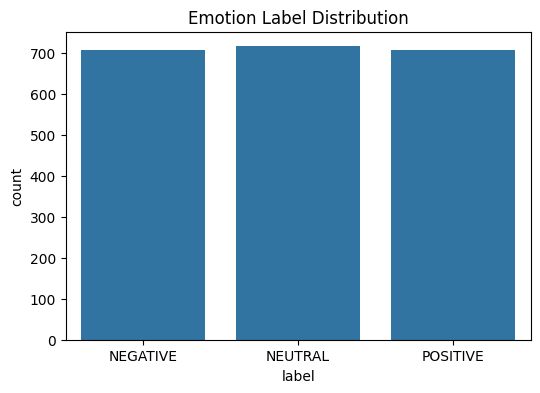

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(x=label_column, data=df)
plt.title("Emotion Label Distribution")
plt.show()

In [12]:
df[feature_columns].describe()

,# mean_0_a,mean_1_a,mean_2_a,mean_3_a,mean_4_a,mean_d_0_a,mean_d_1_a,mean_d_2_a,mean_d_3_a,mean_d_4_a,...,fft_740_b,fft_741_b,fft_742_b,fft_743_b,fft_744_b,fft_745_b,fft_746_b,fft_747_b,fft_748_b,fft_749_b
count,2132.000000,2132.000000,2132.000000,2132.000000,2132.000000,2132.000000,2132.000000,2132.000000,2132.000000,2132.000000,...,2132.000000,2132.000000,2132.000000,2132.000000,2132.000000,2132.000000,2132.000000,2132.000000,2132.000000,2132.000000
mean,15.256914,27.012462,-104.975629,13.605898,24.150483,0.025378,0.052282,0.301655,0.036793,0.083567,...,-22.938971,104.946111,-51.973647,-51.973647,104.946111,-6.934144,95.104886,-49.061255,-49.061255,95.104886
std,15.284621,9.265141,206.271960,16.874676,14.187340,17.981796,8.509174,68.098894,17.010031,18.935378,...,298.034311,212.532721,112.160233,112.160233,212.532721,281.040552,203.194976,106.486317,106.486317,203.194976
min,-61.300000,-114.000000,-970.000000,-137.000000,-217.000000,-218.000000,-255.000000,-1360.000000,-203.000000,-553.000000,...,-1180.000000,-921.000000,-504.000000,-504.000000,-921.000000,-1160.000000,-1010.000000,-521.000000,-521.000000,-1010.000000
25%,6.577500,26.075000,-195.000000,4.857500,23.600000,-3.105000,-1.340000,-4.002500,-2.905000,-2.622500,...,-106.500000,-8.365000,-92.900000,-92.900000,-8.365000,-102.500000,-8.837500,-87.150000,-87.150000,-8.837500
50%,14.100000,30.000000,14.950000,15.400000,25.200000,-0.044600,0.132000,0.957500,-0.099750,0.146500,...,83.850000,12.150000,-21.800000,-21.800000,12.150000,89.700000,13.400000,-24.100000,-24.100000,13.400000
75%,27.700000,31.400000,29.600000,26.500000,26.800000,2.920000,1.540000,6.735000,2.535000,2.870000,...,154.000000,177.000000,12.025000,12.025000,177.000000,153.000000,149.250000,10.925000,10.925000,149.250000
max,304.000000,42.300000,661.000000,206.000000,213.000000,402.000000,257.000000,1150.000000,349.000000,444.000000,...,1070.000000,843.000000,1490.000000,1490.000000,843.000000,1180.000000,888.000000,1670.000000,1670.000000,888.000000


In [13]:
X = df[feature_columns].values
y = df[label_column].values

In [14]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Encoded labels:", np.unique(y_encoded))

Encoded labels: [0 1 2]


In [15]:
print(X.shape)


(2132, 2548)


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)


In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [18]:
n_channels = 14
n_features = X_train_scaled.shape[1]
timesteps = n_features // n_channels
X_train_rnn = X_train_scaled.reshape(
    X_train_scaled.shape[0],
    timesteps,
    n_channels
)
X_val_rnn = X_val_scaled.reshape(
    X_val_scaled.shape[0],
    timesteps,
    n_channels
)

X_test_rnn = X_test_scaled.reshape(
    X_test_scaled.shape[0],
    timesteps,
    n_channels
)


In [19]:
print("Final X_train shape:", X_train_rnn.shape)
print("Final X_val shape:", X_val_rnn.shape)
print("Final X_test shape:", X_test_rnn.shape)

Final X_train shape: (1492, 182, 14)
Final X_val shape: (320, 182, 14)
Final X_test shape: (320, 182, 14)


In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.regularizers import l2

input_shape = (timesteps, n_channels)
num_classes = 3

model_lstm = Sequential([
    Input(shape=input_shape),

    LSTM(
        64,
        return_sequences=True,
        kernel_regularizer=l2(0.0005),
        recurrent_regularizer=l2(0.0005)
    ),
    Dropout(0.3),

    LSTM(
        32,
        kernel_regularizer=l2(0.0005),
        recurrent_regularizer=l2(0.0005)
    ),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(num_classes, activation='softmax')
])


In [21]:
from tensorflow.keras.optimizers import Adam

loss_fn = 'sparse_categorical_crossentropy'

model_lstm.compile(
    optimizer=Adam(learning_rate=0.0005, clipnorm=1.0),
    loss=loss_fn,
    metrics=['accuracy']
)


In [22]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

history_lstm = model_lstm.fit(
    X_train_rnn, y_train,
    validation_data=(X_val_rnn, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.5772 - loss: 1.0951 - val_accuracy: 0.8406 - val_loss: 0.7816
Epoch 2/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8115 - loss: 0.7105 - val_accuracy: 0.8594 - val_loss: 0.4658
Epoch 3/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.8870 - loss: 0.4347 - val_accuracy: 0.8844 - val_loss: 0.3666
Epoch 4/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8982 - loss: 0.3916 - val_accuracy: 0.9000 - val_loss: 0.3541
Epoch 5/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8954 - loss: 0.3569 - val_accuracy: 0.9000 - val_loss: 0.3289
Epoch 6/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9099 - loss: 0.3436 - val_accuracy: 0.9031 - val_loss: 0.3115
Epoch 7/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9147 - loss: 0.3098 - val_accuracy: 0.8969 - val_loss: 0.3070
Epoch 8/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9022 - loss: 0.3349 - val_accuracy: 0.9187 - v

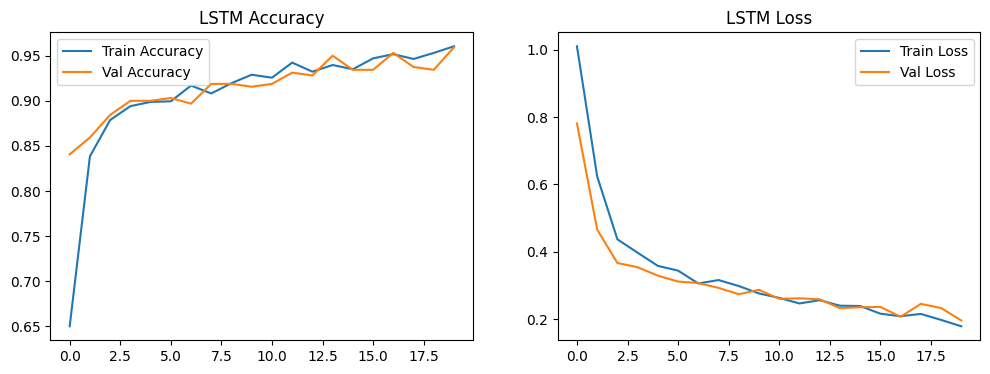

In [23]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history_lstm.history['accuracy'], label='Train Accuracy')
plt.plot(history_lstm.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('LSTM Accuracy')

# Plot Loss
plt.subplot(1,2,2)
plt.plot(history_lstm.history['loss'], label='Train Loss')
plt.plot(history_lstm.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('LSTM Loss')

plt.show()

In [24]:
test_loss, test_accuracy = model_lstm.evaluate(
    X_test_rnn,
    y_test,
    verbose=0
)

print("LSTM Test Accuracy:", test_accuracy)

LSTM Test Accuracy: 0.918749988079071


In [25]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_pred_lstm = np.argmax(model_lstm.predict(X_test_rnn), axis=1)

print("LSTM Classification Report:")
print(classification_report(y_test, y_pred_lstm, target_names=label_encoder.classes_))

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
LSTM Classification Report:
              precision    recall  f1-score   support

    NEGATIVE       0.90      0.89      0.90       107
     NEUTRAL       1.00      0.96      0.98       107
    POSITIVE       0.86      0.91      0.88       106

    accuracy                           0.92       320
   macro avg       0.92      0.92      0.92       320
weighted avg       0.92      0.92      0.92       320



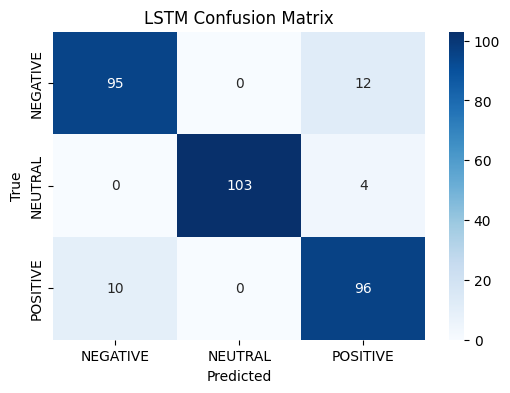

In [26]:
cm = confusion_matrix(y_test, y_pred_lstm)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("LSTM Confusion Matrix")
plt.show()

### **GRU Model**

In [35]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

input_shape = (182, 14)
num_classes = 3

model_gru = Sequential([
    GRU(
        64,
        return_sequences=True,
        input_shape=input_shape,
        kernel_regularizer=l2(0.0005),
        recurrent_regularizer=l2(0.0005)
    ),
    Dropout(0.3),

    GRU(
        32,
        kernel_regularizer=l2(0.0005),
        recurrent_regularizer=l2(0.0005)
    ),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(num_classes, activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [36]:
model_gru.compile(
    optimizer=Adam(learning_rate=0.0005, clipnorm=1.0),
    loss=loss_fn,
    metrics=['accuracy']
)


In [37]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)


history_gru = model_gru.fit(
    X_train_rnn, y_train,
    validation_data=(X_val_rnn, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.5625 - loss: 1.1178 - val_accuracy: 0.8250 - val_loss: 0.8518
Epoch 2/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7767 - loss: 0.8049 - val_accuracy: 0.8781 - val_loss: 0.4921
Epoch 3/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8262 - loss: 0.5490 - val_accuracy: 0.8875 - val_loss: 0.4023
Epoch 4/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8722 - loss: 0.4397 - val_accuracy: 0.8969 - val_loss: 0.3618
Epoch 5/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8710 - loss: 0.4080 - val_accuracy: 0.9000 - val_loss: 0.3426
Epoch 6/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8884 - loss: 0.4063 - val_accuracy: 0.9031 - val_loss: 0.3242
Epoch 7/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.9118 - loss: 0.3347 - val_accuracy: 0.9031 - val_loss: 0.3350
Epoch 8/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.9187 - loss: 0.3058 - val_accuracy: 0.9094 - v

In [38]:
y_pred_gru = np.argmax(model_gru.predict(X_test_rnn), axis=1)

print("GRU Classification Report:")
print(classification_report(y_test, y_pred_gru, target_names=label_encoder.classes_))

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
GRU Classification Report:
              precision    recall  f1-score   support

    NEGATIVE       0.89      0.97      0.93       107
     NEUTRAL       0.98      0.96      0.97       107
    POSITIVE       0.93      0.86      0.89       106

    accuracy                           0.93       320
   macro avg       0.93      0.93      0.93       320
weighted avg       0.93      0.93      0.93       320



In [39]:
test_loss_gru, test_acc_gru = model_gru.evaluate(
    X_test_rnn,
    y_test,
    verbose=0
)

print("GRU Test Accuracy:", test_acc_gru)

GRU Test Accuracy: 0.9312499761581421


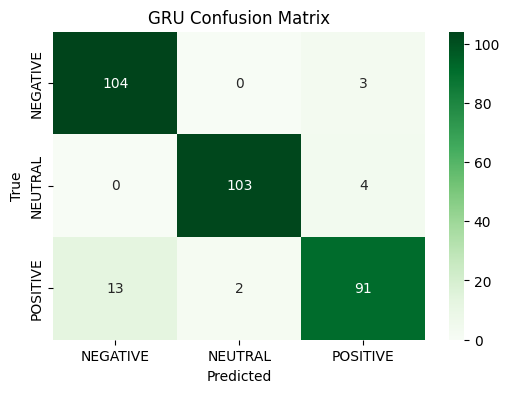

In [40]:
cm_gru = confusion_matrix(y_test, y_pred_gru)

plt.figure(figsize=(6,4))
sns.heatmap(cm_gru, annot=True, fmt='d',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            cmap='Greens')

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("GRU Confusion Matrix")
plt.show()

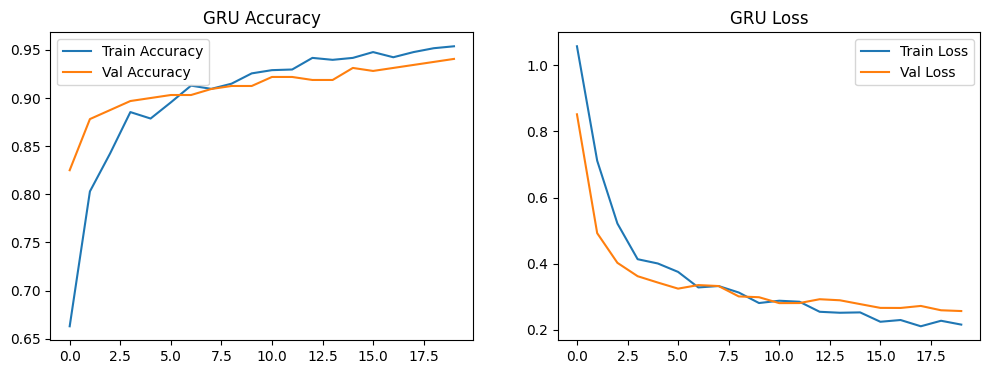

In [41]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history_gru.history['accuracy'], label='Train Accuracy')
plt.plot(history_gru.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('GRU Accuracy')


plt.subplot(1,2,2)
plt.plot(history_gru.history['loss'], label='Train Loss')
plt.plot(history_gru.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('GRU Loss')

plt.show()

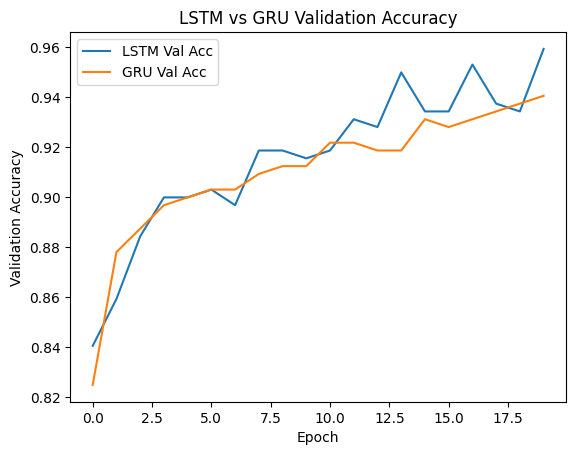

In [42]:
import matplotlib.pyplot as plt

def plot_compare(lstm_hist, gru_hist):
    plt.figure()
    plt.plot(lstm_hist.history['val_accuracy'], label='LSTM Val Acc')
    plt.plot(gru_hist.history['val_accuracy'], label='GRU Val Acc')
    plt.xlabel('Epoch')
    plt.ylabel('Validation Accuracy')
    plt.legend()
    plt.title('LSTM vs GRU Validation Accuracy')
    plt.show()

plot_compare(history_lstm, history_gru)
